# Zomato Kolkata Restaurant Data Analysis

###  Data Analysis Project

This notebook performs:
- Basic data loading and inspection
- Data cleaning
- Exploratory data analysis using **Pandas, NumPy and Matplotlib**
- A simple **Scikit-learn Linear Regression** model to estimate restaurant average cost

The goal is to understand restaurant trends in Kolkata.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


## 2. Load the Dataset

This cell works in Google Colab. If the CSV is not already present, it will ask you to upload it.


In [2]:
import os

FILE_NAME = "Zomato_Kolkata_Restaurants.csv"

if not os.path.exists(FILE_NAME):
    try:
        from google.colab import files
        print(f"Please upload {FILE_NAME}")
        uploaded = files.upload()

        if FILE_NAME not in uploaded:
            csv_files = [name for name in uploaded if name.lower().endswith(".csv")]
            if not csv_files:
                raise FileNotFoundError("No CSV file was uploaded.")
            FILE_NAME = csv_files[0]
    except ImportError:
        raise FileNotFoundError(
            f"{FILE_NAME} was not found. Put the CSV in the same folder as this notebook."
        )

df = pd.read_csv(FILE_NAME)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4923, 19)


,Name,URL,Cuisines,Area,Timing,Full_Address,PhoneNumber,IsHomeDelivery,isTakeaway,isIndoorSeating,isVegOnly,Dinner Ratings,Dinner Reviews,Delivery Ratings,Delivery Reviews,KnownFor,PopularDishes,PeopleKnownFor,AverageCost
0,Jyoti Vihar,https://www.zomato.com/kolkata/jyoti-vihar-cam...,South Indian,"Camac Street Area, Kolkata",Opens tomorrow at 10am,"3A/1, Ho Chi Minh Sarani, Camac Street Area, K...",+919748084091,1,1,1,1,4.4,930,4.1,5498,South Indian Delicacies,"Milk Upma, Jyoti Vihar, Vada Sambar, Filtered ...","South Indian Food, Good Crowd, Excellent Place...",300
1,WOW! Momo,https://www.zomato.com/kolkata/wow-momo-park-s...,"Momos, Fast Food, Tibetan","Park Street Area, Kolkata",9am – 3am (Today),"57, Park Street, Beside Vodafone Store, Park S...",+917604053802,1,1,1,0,4.0,469,4.1,11100,NaN,"Tandoori Paneer Momos, Momo Platter, Chocolate...","Comfortable Seating Area, Staff Service, Famil...",350
2,Zam Zam,https://www.zomato.com/kolkata/zam-zam-park-ci...,"Biryani, Rolls","Park Circus Area, Kolkata",Opens at 12noon,"28/A, Syed Amir Ali Avenue, Park Circus Area, ...",+919748710818,1,1,1,0,4.4,1901,4.3,83100,NaN,"Beef Malai, Beef Bhuna, Hariyali Chicken, Sahi...","Ordering Process, Gastronomical Experience, Co...",500
3,Daily Bhoj,https://www.zomato.com/kolkata/daily-bhoj-topsia,Bengali,"Topsia, Kolkata",NaN,"139/1G, Tljala Road, Topsia, Kolkata",+919330778809,1,0,0,0,-,0,3.9,2260,NaN,NaN,"Great Portions, Worth the Money, Timely Servic...",150
4,Behnam,https://www.zomato.com/kolkata/behnam-topsia,"Biryani, North Indian, Mughlai, Rolls, Kebab, ...","Topsia, Kolkata",Opens at 11am,"139/1G, Tiljala Road, Near OYO Townhouse 229, ...",+919330778809,1,1,0,0,-,0,2.9,151,NaN,NaN,"Worth the Money, Timely Service, Great Portion...",200


## 3. Understand the Data

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))


Rows: 4923
Columns: 19

Column names:
['Name', 'URL', 'Cuisines', 'Area', 'Timing', 'Full_Address', 'PhoneNumber', 'IsHomeDelivery', 'isTakeaway', 'isIndoorSeating', 'isVegOnly', 'Dinner Ratings', 'Dinner Reviews', 'Delivery Ratings', 'Delivery Reviews', 'KnownFor', 'PopularDishes', 'PeopleKnownFor', 'AverageCost']

Data types:
Name                object
URL                 object
Cuisines            object
Area                object
Timing              object
Full_Address        object
PhoneNumber         object
IsHomeDelivery       int64
isTakeaway           int64
isIndoorSeating      int64
isVegOnly            int64
Dinner Ratings      object
Dinner Reviews       int64
Delivery Ratings    object
Delivery Reviews     int64
KnownFor            object
PopularDishes       object
PeopleKnownFor      object
AverageCost          int64
dtype: object

Missing values:
KnownFor            4724
PopularDishes       3919
PeopleKnownFor      2884
Timing              1642
Cuisines               0
N

## 4. Basic Data Cleaning

The ratings columns contain `-` for some restaurants. We convert ratings to numeric values and treat invalid entries as missing values.

For the analysis, missing text fields are filled with `"Unknown"`. Duplicate rows are also removed.


In [4]:
# Keep a copy of the original data
clean_df = df.copy()

# Remove duplicate rows
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# Convert ratings to numeric; '-' becomes NaN
rating_columns = ["Dinner Ratings", "Delivery Ratings"]

for col in rating_columns:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# Fill missing descriptive text fields
text_columns = ["Timing", "KnownFor", "PopularDishes", "PeopleKnownFor"]

for col in text_columns:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna("Unknown")

# Make sure AverageCost is numeric
clean_df["AverageCost"] = pd.to_numeric(clean_df["AverageCost"], errors="coerce")

print("Shape after removing duplicates:", clean_df.shape)
print("\nMissing values in important numeric columns:")
print(clean_df[["Dinner Ratings", "Delivery Ratings", "AverageCost"]].isnull().sum())

clean_df.head()


Shape after removing duplicates: (4923, 19)

Missing values in important numeric columns:
Dinner Ratings      3026
Delivery Ratings    1120
AverageCost            0
dtype: int64


,Name,URL,Cuisines,Area,Timing,Full_Address,PhoneNumber,IsHomeDelivery,isTakeaway,isIndoorSeating,isVegOnly,Dinner Ratings,Dinner Reviews,Delivery Ratings,Delivery Reviews,KnownFor,PopularDishes,PeopleKnownFor,AverageCost
0,Jyoti Vihar,https://www.zomato.com/kolkata/jyoti-vihar-cam...,South Indian,"Camac Street Area, Kolkata",Opens tomorrow at 10am,"3A/1, Ho Chi Minh Sarani, Camac Street Area, K...",+919748084091,1,1,1,1,4.4,930,4.1,5498,South Indian Delicacies,"Milk Upma, Jyoti Vihar, Vada Sambar, Filtered ...","South Indian Food, Good Crowd, Excellent Place...",300
1,WOW! Momo,https://www.zomato.com/kolkata/wow-momo-park-s...,"Momos, Fast Food, Tibetan","Park Street Area, Kolkata",9am – 3am (Today),"57, Park Street, Beside Vodafone Store, Park S...",+917604053802,1,1,1,0,4.0,469,4.1,11100,Unknown,"Tandoori Paneer Momos, Momo Platter, Chocolate...","Comfortable Seating Area, Staff Service, Famil...",350
2,Zam Zam,https://www.zomato.com/kolkata/zam-zam-park-ci...,"Biryani, Rolls","Park Circus Area, Kolkata",Opens at 12noon,"28/A, Syed Amir Ali Avenue, Park Circus Area, ...",+919748710818,1,1,1,0,4.4,1901,4.3,83100,Unknown,"Beef Malai, Beef Bhuna, Hariyali Chicken, Sahi...","Ordering Process, Gastronomical Experience, Co...",500
3,Daily Bhoj,https://www.zomato.com/kolkata/daily-bhoj-topsia,Bengali,"Topsia, Kolkata",Unknown,"139/1G, Tljala Road, Topsia, Kolkata",+919330778809,1,0,0,0,NaN,0,3.9,2260,Unknown,Unknown,"Great Portions, Worth the Money, Timely Servic...",150
4,Behnam,https://www.zomato.com/kolkata/behnam-topsia,"Biryani, North Indian, Mughlai, Rolls, Kebab, ...","Topsia, Kolkata",Opens at 11am,"139/1G, Tiljala Road, Near OYO Townhouse 229, ...",+919330778809,1,1,0,0,NaN,0,2.9,151,Unknown,Unknown,"Worth the Money, Timely Service, Great Portion...",200


## 5. Summary Statistics

In [5]:
numeric_cols = [
    "Dinner Ratings",
    "Dinner Reviews",
    "Delivery Ratings",
    "Delivery Reviews",
    "AverageCost"
]

clean_df[numeric_cols].describe().round(2)


,Dinner Ratings,Dinner Reviews,Delivery Ratings,Delivery Reviews,AverageCost
count,1897.00,4923.00,3803.00,4923.00,4923.00
mean,3.65,155.04,3.88,1719.19,341.01
std,0.47,538.58,0.33,5489.83,332.62
min,2.00,0.00,2.30,0.00,50.00
25%,3.30,0.00,3.70,18.00,150.00
50%,3.70,0.00,4.00,147.00,250.00
75%,4.00,47.00,4.10,992.00,400.00
max,4.90,12700.00,4.60,142600.00,4000.00


## 6. Top Areas by Number of Restaurants

Area
New Town, Kolkata               347
Chinar Park, Kolkata            226
Baguihati, Kolkata              203
Behala, Kolkata                 194
Sector 5, Salt Lake, Kolkata    177
Tollygunge, Kolkata             177
Dum Dum, Kolkata                132
Kestopur, Kolkata               123
Jadavpur, Kolkata               122
Sector 1, Salt Lake, Kolkata    114
Name: count, dtype: int64


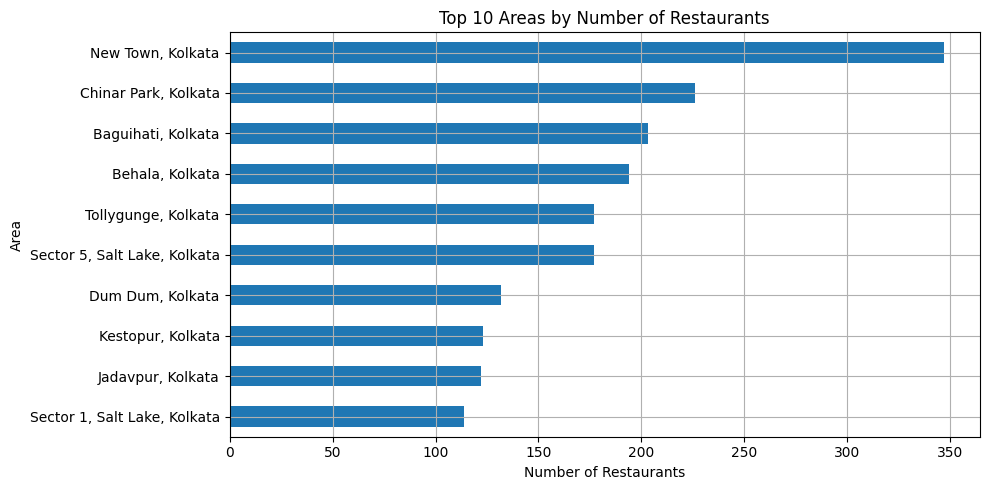

In [6]:
top_areas = clean_df["Area"].value_counts().head(10)

print(top_areas)

top_areas.sort_values().plot(kind="barh")
plt.title("Top 10 Areas by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Area")
plt.tight_layout()
plt.show()


## 7. Most Common Cuisines

Many restaurants serve multiple cuisines, so we split the cuisine field and count individual cuisine names.


Cuisines
Chinese         1889
North Indian    1682
Fast Food       1659
Beverages       1166
Desserts         941
Biryani          861
Bengali          677
Rolls            488
Mughlai          449
Sandwich         362
Name: count, dtype: int64


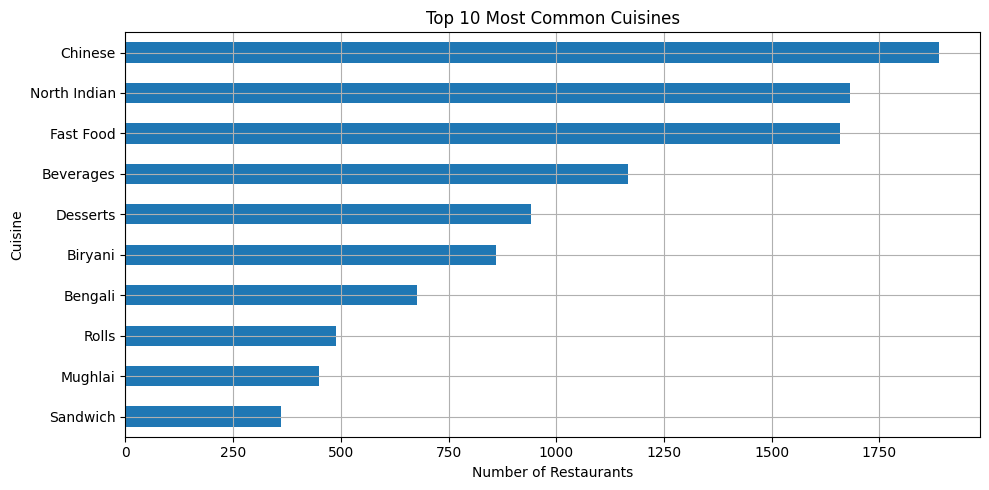

In [7]:
cuisine_counts = (
    clean_df["Cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

print(cuisine_counts)

cuisine_counts.sort_values().plot(kind="barh")
plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()


## 8. Average Restaurant Cost Distribution

Mean average cost: 341.01
Median average cost: 250.0


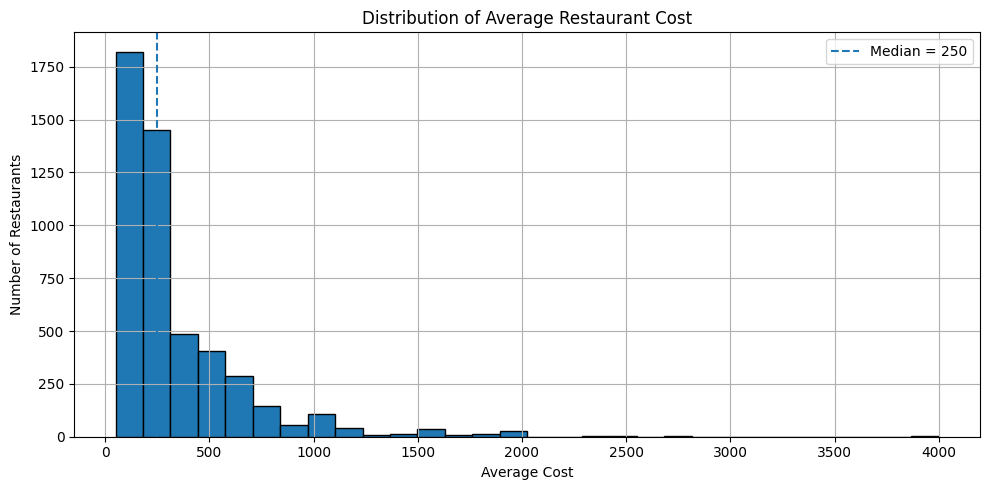

In [8]:
median_cost = clean_df["AverageCost"].median()
mean_cost = clean_df["AverageCost"].mean()

print("Mean average cost:", round(mean_cost, 2))
print("Median average cost:", round(median_cost, 2))

plt.hist(clean_df["AverageCost"].dropna(), bins=30, edgecolor="black")
plt.axvline(median_cost, linestyle="--", label=f"Median = {median_cost:.0f}")
plt.title("Distribution of Average Restaurant Cost")
plt.xlabel("Average Cost")
plt.ylabel("Number of Restaurants")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Restaurant Service Features

We compare the availability of home delivery, takeaway, indoor seating, and veg-only restaurants.


Home Delivery     99.9%
Takeaway          68.6%
Indoor Seating    39.8%
Veg Only           6.9%
dtype: object


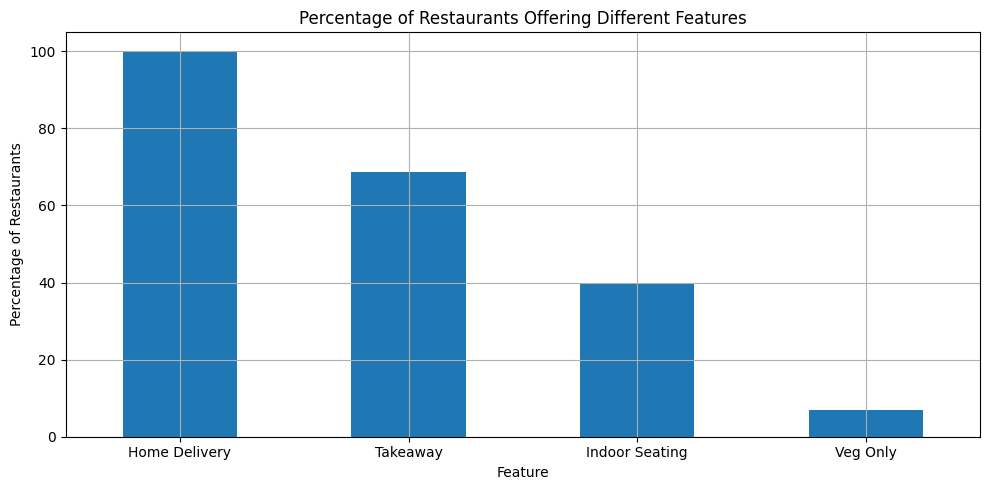

In [9]:
service_cols = ["IsHomeDelivery", "isTakeaway", "isIndoorSeating", "isVegOnly"]

service_percentages = (clean_df[service_cols].mean() * 100).round(1)
service_percentages.index = ["Home Delivery", "Takeaway", "Indoor Seating", "Veg Only"]

print(service_percentages.astype(str) + "%")

service_percentages.plot(kind="bar")
plt.title("Percentage of Restaurants Offering Different Features")
plt.ylabel("Percentage of Restaurants")
plt.xlabel("Feature")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Rating vs Average Cost

This checks whether more expensive restaurants generally have higher dinner ratings.


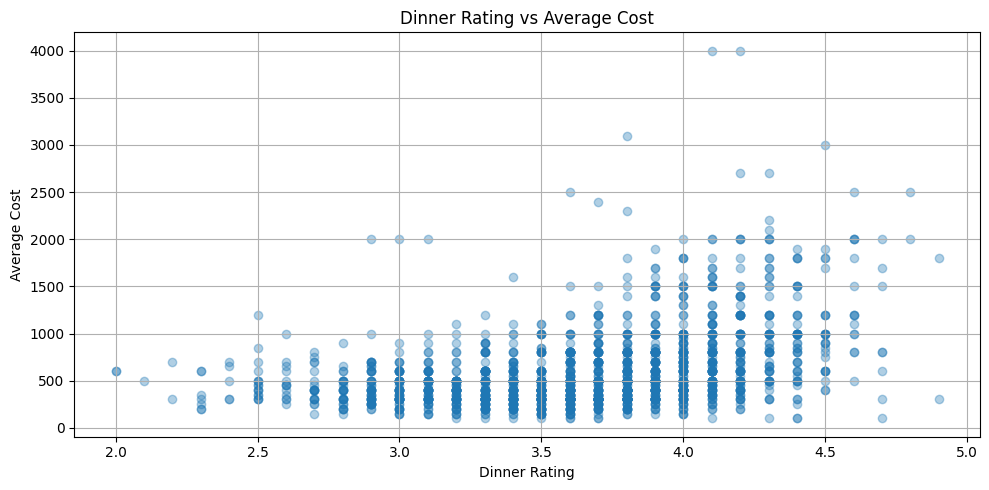

Correlation between Dinner Rating and Average Cost: 0.397


In [10]:
rating_cost_df = clean_df.dropna(subset=["Dinner Ratings", "AverageCost"])

plt.scatter(
    rating_cost_df["Dinner Ratings"],
    rating_cost_df["AverageCost"],
    alpha=0.35
)
plt.title("Dinner Rating vs Average Cost")
plt.xlabel("Dinner Rating")
plt.ylabel("Average Cost")
plt.tight_layout()
plt.show()

correlation = rating_cost_df["Dinner Ratings"].corr(rating_cost_df["AverageCost"])
print("Correlation between Dinner Rating and Average Cost:", round(correlation, 3))


## 11. Top Rated Restaurants

To avoid ranking restaurants with very few reviews too highly, we only consider restaurants with at least 100 dinner reviews.


In [11]:
top_rated = (
    clean_df[
        (clean_df["Dinner Reviews"] >= 100) &
        (clean_df["Dinner Ratings"].notna())
    ]
    .sort_values(
        by=["Dinner Ratings", "Dinner Reviews"],
        ascending=[False, False]
    )
    [["Name", "Area", "Cuisines", "Dinner Ratings", "Dinner Reviews", "AverageCost"]]
    .head(10)
)

top_rated


,Name,Area,Cuisines,Dinner Ratings,Dinner Reviews,AverageCost
56,Barbeque Nation,"Wellesley, Kolkata","BBQ, Chinese, Kebab, North Indian, Desserts",4.9,5619,1800
72,Natural Ice Cream,"Park Street Area, Kolkata","Ice Cream, Desserts",4.9,2419,300
3386,Asia Kitchen By Mainland China,"Acropolis Mall, Kasba, Kolkata","Chinese, Momos, Thai, Asian, Seafood, Sushi, B...",4.8,2417,2000
264,Pa Pa Ya,"Park Street Area, Kolkata","Asian, Chinese, Japanese, Thai",4.8,1975,2500
44,India Restaurant,"Kidderpore, Kolkata","Biryani, Mughlai, North Indian, Kebab, Chinese",4.7,4571,800
907,My Big Fat Belly,"Bhawanipur, Kolkata","Burger, Pizza, Pasta, Continental, Italian, Be...",4.7,2784,600
110,Oh! Calcutta,"Forum Mall, Elgin, Kolkata","Bengali, Seafood",4.7,1997,2000
1053,Momo I Am,"Sector 5, Salt Lake, Kolkata","Chinese, Momos, Tibetan, Asian",4.7,1653,800
3214,Balaram Mullick & Radharaman Mullick Sweets,"Bhawanipur, Kolkata","Mishti, Desserts, Street Food",4.7,1379,100
248,The Fatty Bao,"Fort Knox, Camac Street Area, Kolkata","Asian, Sushi, Japanese, Chinese, Thai, Momos, ...",4.7,1372,1500


## 12. Simple Machine Learning Model

We have build a basic **Linear Regression** model to estimate `AverageCost`.

Features used:
- Dinner rating
- Dinner reviews
- Delivery rating
- Delivery reviews
- Home delivery
- Takeaway
- Indoor seating
- Veg-only flag


In [12]:
model_features = [
    "Dinner Ratings",
    "Dinner Reviews",
    "Delivery Ratings",
    "Delivery Reviews",
    "IsHomeDelivery",
    "isTakeaway",
    "isIndoorSeating",
    "isVegOnly"
]

model_df = clean_df[model_features + ["AverageCost"]].copy()

# Replace missing numeric values with column medians
for col in model_features:
    model_df[col] = model_df[col].fillna(model_df[col].median())

model_df["AverageCost"] = model_df["AverageCost"].fillna(
    model_df["AverageCost"].median()
)

X = model_df[model_features]
y = model_df["AverageCost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 3))


Mean Absolute Error: 141.54
R² Score: 0.463


## 13. Actual vs Predicted Cost

In [13]:
comparison = pd.DataFrame({
    "Actual Cost": y_test.values,
    "Predicted Cost": predictions
})

comparison.head(10)


,Actual Cost,Predicted Cost
0,200,196.665925
1,150,191.851018
2,200,190.441039
3,50,191.763123
4,300,174.374675
5,500,431.307070
6,100,191.736079
7,100,191.851018
8,500,522.379651
9,2000,563.212865


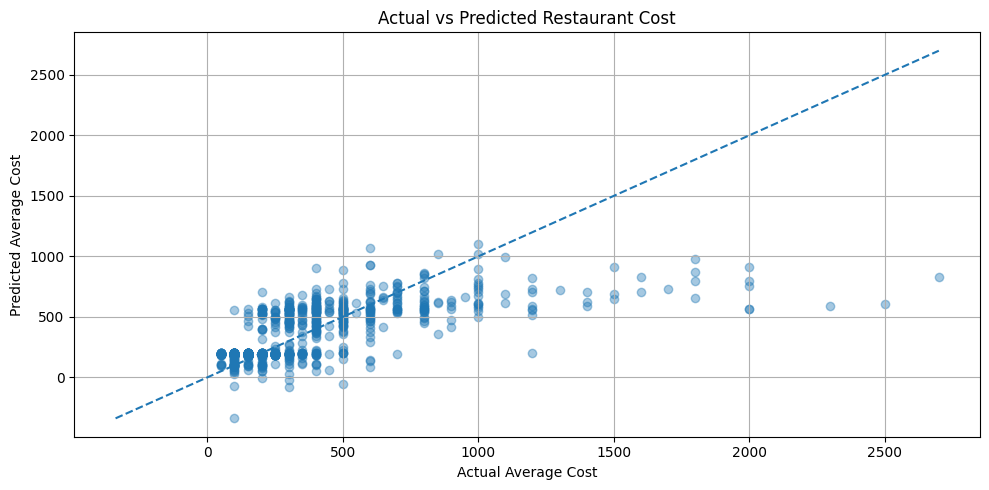

In [14]:
plt.scatter(y_test, predictions, alpha=0.4)
plt.xlabel("Actual Average Cost")
plt.ylabel("Predicted Average Cost")
plt.title("Actual vs Predicted Restaurant Cost")

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()


## 14. Model Coefficients

The coefficient table gives a simple view of how each input feature is related to predicted restaurant cost in this linear model.


In [15]:
coefficients = pd.DataFrame({
    "Feature": model_features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

coefficients


,Feature,Coefficient
6,isIndoorSeating,361.398027
0,Dinner Ratings,191.233928
7,isVegOnly,-91.260208
4,IsHomeDelivery,23.521052
2,Delivery Ratings,9.772672
5,isTakeaway,8.645366
1,Dinner Reviews,0.139361
3,Delivery Reviews,-0.006761


## 15. Key Takeaways

After running the notebook, use the generated tables and graphs to discuss:

1. Which Kolkata areas contain the most restaurants.
2. Which cuisines are the most common.
3. The typical average restaurant cost.
4. How common delivery, takeaway, indoor seating, and veg-only options are.
5. Whether dinner ratings appear strongly related to restaurant cost.
6. How well a simple linear-regression baseline can estimate average restaurant cost.

